# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

1. We use these because real data usually isn’t just a straight line. They make the model more flexible, account for hidden stuff, and help capture more complex patterns than basic linear models.

2. Binary and categorical cross entropy work well because logistic regression gives probabilities, and these loss functions basically check how close those are to the actual outcomes. They also penalize the model more when it’s confidently wrong, which helps it learn better.

3. True. Logistic regression is still a linear model because it’s linear in the inputs, but then it applies a sigmoid function to turn that into a probability.

4. False. Logistic regression is actually used for classification, it predicts probabilities, and then you just apply a threshold to assign classes.

5. No. In logistic regression, the coefficient represents the change in the log-odds, not the predicted value itself, for a 1 unit increase in the feature.

6. False. Logistic regression is actually linear in the inputs, so it can’t capture complex patterns on its own, feature engineering is still important to help it model non-linear relationships.

7. False. Logistic regression isn’t always better, it’s just used for classification problems, while linear regression is better for predicting continuous values, so it depends on the problem.



**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [3]:
import pandas as pd
df = pd.read_csv("/content/data/data.csv", sep=";")
df = df[[
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment",
    "Curricular units 1st sem (approved)",
    "Target"
]]
df = df.dropna()
df["dropout"] = df["Target"].apply(lambda x: 1 if x == "Dropout" else 0)

In [4]:
import statsmodels.api as sm
X = df[[
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment"
]]
y = df["dropout"]
X = sm.add_constant(X)
model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.500966
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                dropout   No. Observations:                 4424
Model:                          Logit   Df Residuals:                     4419
Method:                           MLE   Df Model:                            4
Date:                Tue, 21 Apr 2026   Pseudo R-squ.:                  0.2020
Time:                        23:49:42   Log-Likelihood:                -2216.3
converged:                       True   LL-Null:                       -2777.3
Covariance Type:            nonrobust   LLR p-value:                1.298e-241
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                       0.5352      0.182      2.943      0.003       0.179   

2. Debtor and age at enrollment have positive coefficients, so they are associated with a higher probability of dropping out. Tuition fees up to date and scholarship holder have negative coefficients, so they are associated with a lower probability of dropping out. Being up to date on tuition appears to reduce dropout risk since its coefficient is strongly negative.

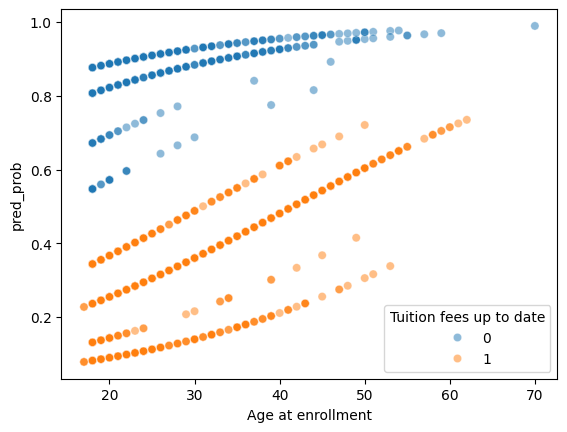

Tuition fees up to date
0    0.865530
1    0.247433
Name: pred_prob, dtype: float64
Difference: 0.6180970381432395


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
df["pred_prob"] = model.predict(X)
sns.scatterplot(
    data=df,
    x="Age at enrollment",
    y="pred_prob",
    hue="Tuition fees up to date",
    alpha=0.5
)
plt.show()
avg_diff = df.groupby("Tuition fees up to date")["pred_prob"].mean()
print(avg_diff)
print("Difference:", avg_diff[0] - avg_diff[1])

3. Being up to date on tuition reduces dropout probability across all ages, but the gap looks biggest for older students, where the predicted dropout risk is higher overall. On average, being up to date on tuition lowers the predicted probability of dropout by about 0.62, which is a pretty large decrease.

In [6]:
from sklearn.metrics import confusion_matrix, accuracy_score
y_pred = model.predict(X)
y_pred = (y_pred >= 0.5).astype(int)
cm = confusion_matrix(y, y_pred)
print(cm)
acc = accuracy_score(y, y_pred)
print("Accuracy:", acc)

[[2841  162]
 [ 891  530]]
Accuracy: 0.7619801084990958


4. The confusion matrix shows that the model correctly classifies most cases, but still makes some errors, especially with dropouts. The overall accuracy is about 76.2%, which means the model is doing a decent job but isn’t perfect.

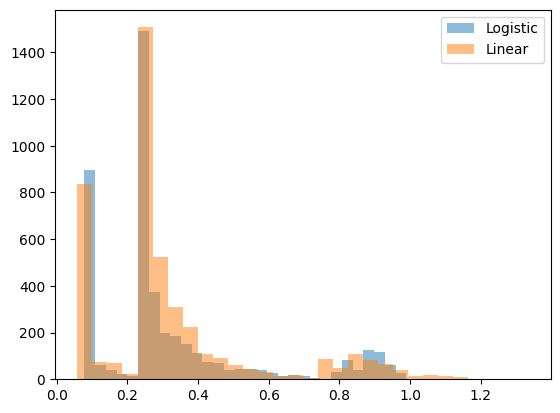

In [7]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
lin_model = sm.OLS(y, X).fit()
df["lin_pred"] = lin_model.predict(X)
plt.hist(df["pred_prob"], bins=30, alpha=0.5, label="Logistic")
plt.hist(df["lin_pred"], bins=30, alpha=0.5, label="Linear")
plt.legend()
plt.show()

5. The logistic regression predictions stay between 0 and 1, while the linear model gives some values above 1, which doesn’t make sense for probabilities. The logistic model also looks more well-behaved and concentrated, while the linear model is more spread out. Overall, logistic regression performs better because it produces realistic probability estimates.

6. Students most at risk are those with debt, not up to date on tuition, older at enrollment, and without scholarships. To help, schools could offer financial support (payment plans, scholarships) and extra advising/support, especially for higher-risk students.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
X_multi = df[[
    "Debtor",
    "Tuition fees up to date",
    "Curricular units 1st sem (approved)"
]]
y_multi = df["Target"]
multi_model = LogisticRegression(multi_class="multinomial", max_iter=1000)
multi_model.fit(X_multi, y_multi)
y_pred_multi = multi_model.predict(X_multi)
cm_multi = confusion_matrix(y_multi, y_pred_multi)
print(cm_multi)
probs = multi_model.predict_proba(X_multi)
print(probs[:5])

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[[1054    0  367]
 [ 280    0  514]
 [ 146    0 2063]]
[[0.68054695 0.21046429 0.10898876]
 [0.69541412 0.1460432  0.15854268]
 [0.95298821 0.04119918 0.00581261]
 [0.11780804 0.1769832  0.70520876]
 [0.18422683 0.21266883 0.60310434]]


7. The confusion matrix shows the model never predicts the Graduate class, so hard classification misses a class. But the predicted probabilities do include all classes, they’re just not the highest, so they don’t get selected.

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

In [9]:
import pandas as pd
df = pd.read_csv("/content/data/cirrhosis.csv")
df = df[["Bilirubin", "Edema", "Drug", "Stage", "Status"]]
df = df.dropna()

In [11]:

df["alive"] = df["Status"].apply(lambda x: 0 if x == "D" else 1)
df_enc = pd.get_dummies(df, columns=["Edema", "Drug"], drop_first=True)
X = df_enc.drop(columns=["Status", "alive"])
y = df_enc["alive"]
X = X.astype(float)
X = sm.add_constant(X)
model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.513607
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                  alive   No. Observations:                  312
Model:                          Logit   Df Residuals:                      306
Method:                           MLE   Df Model:                            5
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.2371
Time:                        00:06:12   Log-Likelihood:                -160.25
converged:                       True   LL-Null:                       -210.06
Covariance Type:            nonrobust   LLR p-value:                 6.324e-20
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            2.9379      0.560      5.248      0.000       1.841       4.035
Bilirubin       -0.3076

2. The drug doesn’t seem to significantly improve survival since its coefficient isn’t statistically significant. Higher bilirubin is associated with lower survival, since its coefficient is negative and significant. Survival decreases as edema gets worse to mild edema doesn’t have a strong effect, but severe edema (Edema_Y) is linked to much lower survival.

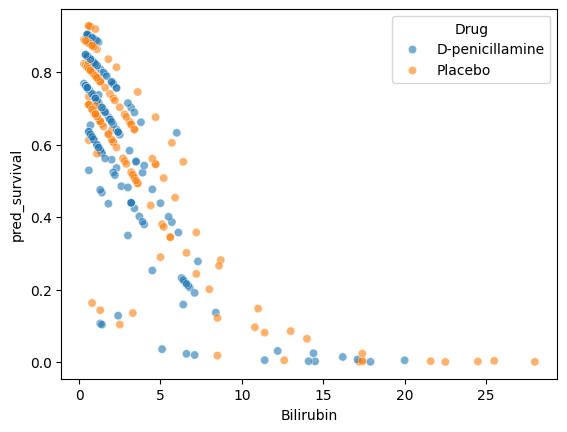

Drug
D-penicillamine    0.588608
Placebo            0.610390
Name: pred_survival, dtype: float64
Difference: -0.021782015452901482


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
df["pred_survival"] = model.predict(X)
sns.scatterplot(
    data=df,
    x="Bilirubin",
    y="pred_survival",
    hue="Drug",
    alpha=0.6
)
plt.show()
avg = df.groupby("Drug")["pred_survival"].mean()
print(avg)
print("Difference:", avg["D-penicillamine"] - avg["Placebo"])

3. The drug doesn’t really show a clear improvement at any specific bilirubin range, the points for both groups mostly overlap across all values.On average, patients taking the drug actually have a slightly lower predicted survival probability (about -0.02), so there’s basically no meaningful improvement.

In [13]:
from sklearn.metrics import confusion_matrix, accuracy_score
y_pred = (model.predict(X) >= 0.5).astype(int)
cm = confusion_matrix(y, y_pred)
print(cm)
acc = accuracy_score(y, y_pred)
print("Accuracy:", acc)

[[ 64  61]
 [ 16 171]]
Accuracy: 0.7532051282051282


4. The overall accuracy is about 75.3%

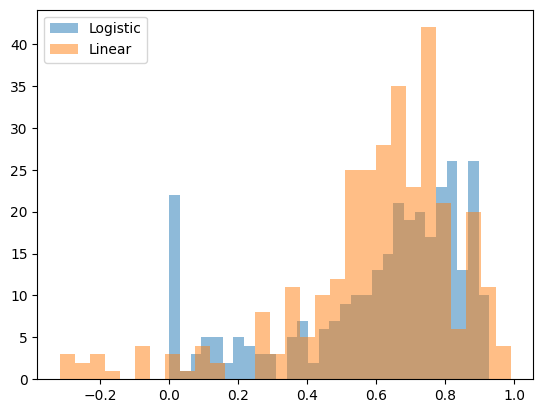

In [14]:
lin_model = sm.OLS(y, X).fit()
df["lin_pred"] = lin_model.predict(X)
plt.hist(df["pred_survival"], bins=30, alpha=0.5, label="Logistic")
plt.hist(df["lin_pred"], bins=30, alpha=0.5, label="Linear")
plt.legend()
plt.show()

5. The logistic model keeps predictions between 0 and 1, while the linear model gives some values below 0 and above 1, which doesn’t make sense for probabilities. The logistic predictions also look more concentrated and realistic, while the linear model is more spread out. Overall, logistic regression performs better because it gives more valid probability estimates.

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
X_stage = df_enc[["Bilirubin", "Edema_S", "Edema_Y"]]
y_stage = df["Stage"]
stage_model = LogisticRegression(max_iter=1000)
stage_model.fit(X_stage, y_stage)
y_pred_stage = stage_model.predict(X_stage)
cm_stage = confusion_matrix(y_stage, y_pred_stage)
print(cm_stage)
probs_stage = stage_model.predict_proba(X_stage)
print(probs_stage[:5])

[[  0   0  16   0]
 [  0   0  63   4]
 [  0   0 105  15]
 [  0   0  79  30]]
[[1.28550372e-05 3.25351316e-02 1.43611431e-01 8.23840583e-01]
 [7.23937578e-02 2.51555267e-01 3.97519699e-01 2.78531276e-01]
 [2.92626485e-02 1.81530850e-01 3.95694470e-01 3.93512032e-01]
 [2.32719781e-02 1.76777228e-01 3.97216502e-01 4.02734292e-01]
 [2.02038998e-02 2.24965391e-01 4.23342268e-01 3.31488440e-01]]


6. The confusion matrix shows the model is basically predicting only stages 3 and 4, and never predicts stages 1 or 2. So the hard classification is missing some classes completely. But the predicted probabilities do include all stages (1–4) for each observation, they’re just usually small for stages 1 and 2, so they don’t get chosen. So overall, the hard classification does not predict every class, but the predicted probabilities do cover every class.

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?

1. For a linear model, the derivative with respect to the kth feature is just bk. So for a 1 unit increase in that feature, the prediction changes by bk, it’s constant and doesn’t depend on anything else.

2. So unlike the linear model, the derivative is not constant, it depends on the predicted probability p^.The effect is largest when p^ ≈0.5, and smaller when p^ is close to 0 or 1. So the coefficient bk(times about 0.25 ≈ 1/4) is a good  estimate of the effect when p^ is around 0.5.

3. A 1 unit increase in xk changes the log odds ratio by bk.So it’s linear in the log-odds scale—the coefficient directly tells you how much the log odds increase or decrease.